# 🥋 Poser — Dual-Stem Feature Fusion Network
**Architecture:** Keras Functional API · Two Bi-LSTM Stems · Multi-Head Attention · Anti-Leakage Clip-Level Split  
**Classes:** GedanBarai · Gyakudzuki · MaeGeri

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {keras.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Aesthetics ────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
BG_COLOR = '#0D1117'
PALETTE  = {'GedanBarai': '#00C9FF', 'Gyakudzuki': '#FF6B6B', 'MaeGeri': '#A8FF78'}

TensorFlow  : 2.18.0
Keras       : 3.12.0
GPU devices : []


## § 1 — Feature Column Definitions

In [2]:
# Upper Body: landmarks 11-22 (x,y,z,v) + angle_08 to angle_13
UPPER_COORDS = [f'{c}{i}' for i in range(11, 23) for c in ['x', 'y', 'z', 'v']]
UPPER_ANGLES = [f'angle_{i:02d}' for i in range(8, 14)]
UPPER_FEATS  = UPPER_COORDS + UPPER_ANGLES   # 48 + 6 = 54

# Lower Body: landmarks 23-32 (x,y,z,v) + angle_00 to angle_07
LOWER_COORDS = [f'{c}{i}' for i in range(23, 33) for c in ['x', 'y', 'z', 'v']]
LOWER_ANGLES = [f'angle_{i:02d}' for i in range(0, 8)]
LOWER_FEATS  = LOWER_COORDS + LOWER_ANGLES   # 40 + 8 = 48

SEQ_LEN        = 30
N_CLASSES      = 3
N_UPPER        = len(UPPER_FEATS)   # 54
N_LOWER        = len(LOWER_FEATS)   # 48

print(f'Upper features: {N_UPPER}  (target 54)')
print(f'Lower features: {N_LOWER}  (target 48)')

Upper features: 54  (target 54)
Lower features: 48  (target 48)


## § 2 — Anti-Leakage Data Loader
Split is done at **clip level**, ensuring no video's frames span both train and test sets.

In [3]:
# ── 2. Anti-Leakage SUBJECT-LEVEL Split (Practitioner Isolation) ─────────────
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

CSV_PATH = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\data\karate_normalized_base.csv"
df = pd.read_csv(CSV_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

# ─ Label encode ──────────────────────────────────────────────────────────────
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['folder_label'])
CLASS_NAMES = le.classes_.tolist()
print(f'Classes: {CLASS_NAMES}')

# ─ Extract Practitioner and View ─────────────────────────────────────────────
def extract_practitioner_and_view(clip_name):
    parts = clip_name.split('_')
    if len(parts) >= 4:
        return parts[2], parts[1] # practitioner_id, view
    return "Unknown", "Unknown"

clip_meta = []
for clip_id, group in df.groupby('clip_id'):
    practitioner, view = extract_practitioner_and_view(clip_id)
    clip_meta.append({
        'clip_id': clip_id,
        'label_enc': group['label_enc'].iloc[0],
        'folder_label': group['folder_label'].iloc[0],
        'practitioner_id': practitioner,
        'view': view
    })
meta_df = pd.DataFrame(clip_meta)

# ── THE FIX: MANUAL GOLDEN TEST SET OVERRIDE ─────────────────────────────────
golden_test_practitioners = {'008', '027', '014', '037'}

test_mask = meta_df['practitioner_id'].isin(golden_test_practitioners)
train_mask = ~test_mask

train_meta = meta_df[train_mask]
test_meta = meta_df[test_mask]

train_clips = train_meta['clip_id'].values
test_clips = test_meta['clip_id'].values

# ─ Verification Checks ───────────────────────────────────────────────────────
print("\n📊 TRAINING SET BALANCE:")
print(pd.crosstab(train_meta['folder_label'], train_meta['view'], margins=True))

print("\n📊 TESTING SET BALANCE:")
print(pd.crosstab(test_meta['folder_label'], test_meta['view'], margins=True))

train_practitioners = set(train_meta['practitioner_id'])
test_practitioners = set(test_meta['practitioner_id'])
leakage = train_practitioners.intersection(test_practitioners)
print(f"\n🛡️ Subject Leakage Check:")
print(f"   Train Humans: {train_practitioners}")
print(f"   Test Humans:  {test_practitioners}")
print(f"   Overlapping Humans: {'✅ ZERO' if not leakage else f'❌ LEAK DETECTED: {leakage}'}")

# ─ Reconstruct frame-level sets ───────────────────────────────────────────────
train_df = df[df['clip_id'].isin(train_clips)].sort_values(['clip_id', 'frame_idx'])
test_df  = df[df['clip_id'].isin(test_clips)].sort_values(['clip_id', 'frame_idx'])

# ─ Builder function ───────────────────────────────────────────────────────────
def build_sequences(sub_df, features):
    clips = sub_df['clip_id'].unique()
    X = np.zeros((len(clips), SEQ_LEN, len(features)), dtype=np.float32)
    y = np.zeros(len(clips), dtype=np.int32)
    for i, clip in enumerate(clips):
        grp = sub_df[sub_df['clip_id'] == clip].sort_values('frame_idx')
        frames = grp[features].values
        X[i, :len(frames)] = frames[:SEQ_LEN]
        y[i] = grp['label_enc'].iloc[0]
    return X, y

print('\nBuilding 3D Tensors...')
X_train_upper, y_train = build_sequences(train_df, UPPER_FEATS)
X_train_lower, _       = build_sequences(train_df, LOWER_FEATS)
X_test_upper,  y_test  = build_sequences(test_df,  UPPER_FEATS)
X_test_lower,  _       = build_sequences(test_df,  LOWER_FEATS)

# ── THE FIX: Define ALL_FEATS for the baseline model ──
ALL_FEATS = UPPER_FEATS + LOWER_FEATS

# Build FULL features for the Baseline Single BiLSTM
X_train_full, _ = build_sequences(train_df, ALL_FEATS)
X_test_full, _  = build_sequences(test_df, ALL_FEATS)

y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat  = to_categorical(y_test,  N_CLASSES)

print(f'Upper Train: {X_train_upper.shape} | Lower Train: {X_train_lower.shape}')
print(f'Baseline Full Train: {X_train_full.shape}')

Loaded: 13,380 rows × 149 cols
Classes: ['GedanBarai', 'Gyakudzuki', 'MaeGeri']

📊 TRAINING SET BALANCE:
view          front  side  All
folder_label                  
GedanBarai       46    62  108
Gyakudzuki       33    83  116
MaeGeri          41   116  157
All             120   261  381

📊 TESTING SET BALANCE:
view          front  side  All
folder_label                  
GedanBarai       13     8   21
Gyakudzuki       13    13   26
MaeGeri          16     2   18
All              42    23   65

🛡️ Subject Leakage Check:
   Train Humans: {'036', '021', '007', '041', '030', '006', '010', '009', '019', '033', '020', '018', '035', '022', '034', '025', '038', '003', '011', '024', '005', '016', '031', '004', '013', '002', '032', '040', '015', '023', '039', '001', '017', '026', '012', '029', '042'}
   Test Humans:  {'027', '037', '008', '014'}
   Overlapping Humans: ✅ ZERO

Building 3D Tensors...
Upper Train: (381, 30, 54) | Lower Train: (381, 30, 48)
Baseline Full Train: (381, 30, 102)


## § 3 — Dual-Stem Fusion Architecture
```
Upper (30, 54) → BiLSTM(64) → Dropout → BiLSTM(32) ─┐
                                                       ├─ Concat → MultiHeadAttention(4 heads) → GlobalAvgPool → Dense(3)
Lower (30, 48) → BiLSTM(64) → Dropout → BiLSTM(32) ─┘
```

In [4]:
def build_dual_stem_model(
    n_upper=54, n_lower=48, seq_len=30, n_classes=3,
    lstm_units_1=64, lstm_units_2=32, num_heads=4, dropout_rate=0.4
):
    # ── Input 1: Upper Body ───────────────────────────────────────────────────
    inp_upper = keras.Input(shape=(seq_len, n_upper), name='upper_body')
    x_up = layers.Bidirectional(
        layers.LSTM(lstm_units_1, return_sequences=True),
        name='bilstm_upper_1'
    )(inp_upper)
    x_up = layers.Dropout(dropout_rate, name='drop_upper')(x_up)
    x_up = layers.Bidirectional(
        layers.LSTM(lstm_units_2, return_sequences=True),
        name='bilstm_upper_2'
    )(x_up)

    # ── Input 2: Lower Body ───────────────────────────────────────────────────
    inp_lower = keras.Input(shape=(seq_len, n_lower), name='lower_body')
    x_lo = layers.Bidirectional(
        layers.LSTM(lstm_units_1, return_sequences=True),
        name='bilstm_lower_1'
    )(inp_lower)
    x_lo = layers.Dropout(dropout_rate, name='drop_lower')(x_lo)
    x_lo = layers.Bidirectional(
        layers.LSTM(lstm_units_2, return_sequences=True),
        name='bilstm_lower_2'
    )(x_lo)

    # ── Fusion Node ───────────────────────────────────────────────────────────
    fused = layers.Concatenate(axis=-1, name='fusion_concat')([x_up, x_lo])  # (batch, 30, 64+64)

    # ── Global Self-Attention (Sensei's Eye) ──────────────────────────────────
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=fused.shape[-1] // num_heads,
        name='sensei_attention'
    )(fused, fused)                               # self-attention
    attn_out = layers.LayerNormalization(name='attn_norm')(attn_out + fused)  # residual
    attn_out = layers.Dropout(0.3, name='drop_attn')(attn_out)

    # ── Readout ───────────────────────────────────────────────────────────────
    pooled = layers.GlobalAveragePooling1D(name='global_avg_pool')(attn_out)
    pooled = layers.Dense(64, activation='relu', name='pre_output')(pooled)
    pooled = layers.Dropout(0.3)(pooled)
    output = layers.Dense(n_classes, activation='softmax', name='technique_output')(pooled)

    model = Model(inputs=[inp_upper, inp_lower], outputs=output, name='DualStemFusion')
    return model

model = build_dual_stem_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "DualStemFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ upper_body          │ (None, 30, 54)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_body          │ (None, 30, 48)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_upper_1      │ (None, 30, 128)   │     60,928 │ upper_body[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_lower_1      │ (None, 30, 128)   │     57,856 │ lower_body[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_upper          │ (None, 30, 128)   │          0 │ bilstm_upper_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lower          │ (None, 30, 128)   │          0 │ bilstm_lower_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_upper_2      │ (None, 30, 64)    │     41,216 │ drop_upper[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_lower_2      │ (None, 30, 64)    │     41,216 │ drop_lower[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 30, 128)   │          0 │ bilstm_upper_2[0… │
│ (Concatenate)       │                   │            │ bilstm_lower_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensei_attention    │ (None, 30, 128)   │     66,048 │ fusion_concat[0]… │
│ (MultiHeadAttentio… │                   │            │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 128)   │          0 │ sensei_attention… │
│                     │                   │            │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm           │ (None, 30, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_attn (Dropout) │ (None, 30, 128)   │          0 │ attn_norm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 128)       │          0 │ drop_attn[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_output (Dense)  │ (None, 64)        │      8,256 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ pre_output[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ technique_output    │ (None, 3)         │        195 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 275,971 (1.05 MB)

 Trainable params: 275,971 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

## § 4 — Training

In [5]:
CKPT_PATH = 'dual_stem_best.keras'

callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=20,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

history = model.fit(
    x=[X_train_upper, X_train_lower],
    y=y_train_cat,
    validation_data=([X_test_upper, X_test_lower], y_test_cat),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4238 - loss: 1.2219
Epoch 1: val_accuracy improved from None to 0.66154, saving model to dual_stem_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 182ms/step - accuracy: 0.4436 - loss: 1.0858 - val_accuracy: 0.6615 - val_loss: 0.8607 - learning_rate: 0.0010
Epoch 2/150
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7326 - loss: 0.7305
Epoch 2: val_accuracy improved from 0.66154 to 0.73846, saving model to dual_stem_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7402 - loss: 0.6974 - val_accuracy: 0.7385 - val_loss: 0.6577 - learning_rate: 0.0010
Epoch 3/150
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7929 - loss: 0.5195
Epoch 3: val_accuracy improved from 0.73846 to 0.86154, saving model to dual_stem_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8241 - loss: 0.4706 - val_accuracy: 0.8615 - val_loss: 0.5337 - learning_rate: 0.0010
Epoch 4/150
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30

##### ==============================================================================
#### ── 5. EVALUATE DUAL-STEM MODEL ───────────────────────────────────────────────
##### ==============================================================================


🔍 Evaluating Dual-Stem Model...

=== Dual-Stem Classification Report ===
              precision    recall  f1-score   support

  GedanBarai     1.0000    0.8571    0.9231        21
  Gyakudzuki     1.0000    0.8846    0.9388        26
     MaeGeri     0.7500    1.0000    0.8571        18

    accuracy                         0.9077        65
   macro avg     0.9167    0.9139    0.9063        65
weighted avg     0.9308    0.9077    0.9111        65



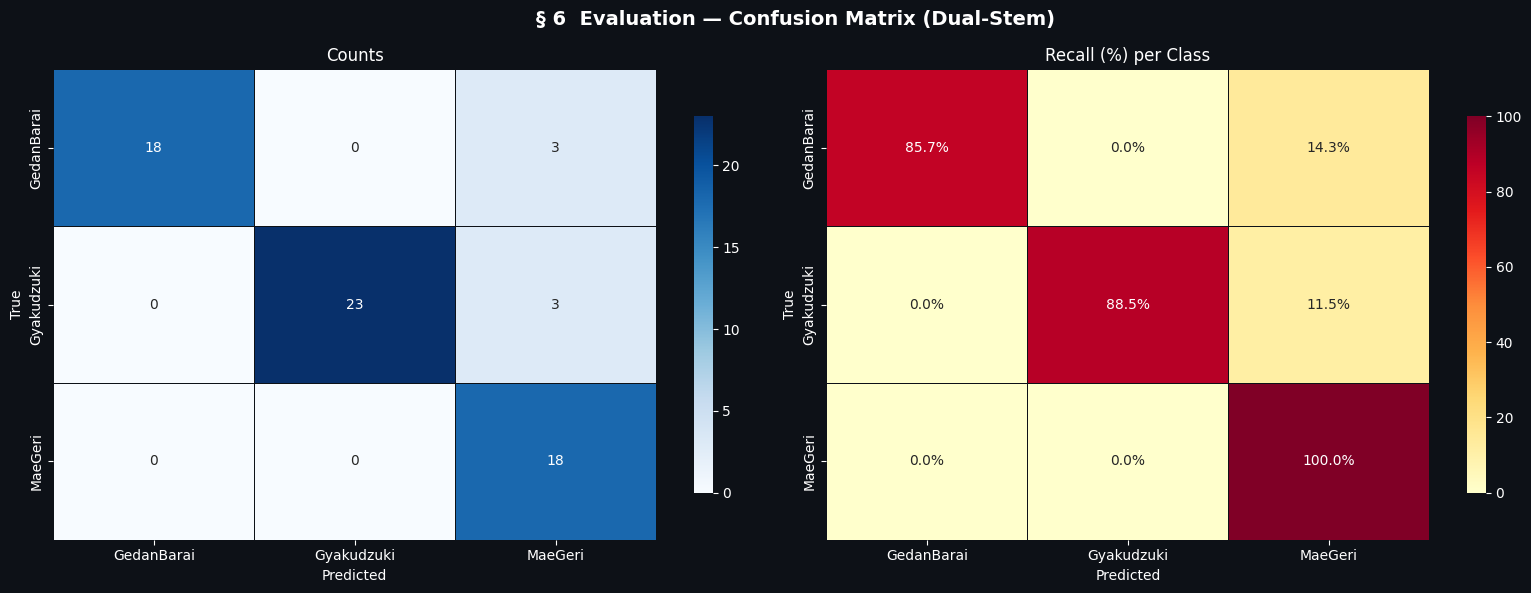


Dual-Stem Test Accuracy : 90.77%


In [6]:
import os
import json
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


print("\n🔍 Evaluating Dual-Stem Model...")
y_pred_probs = model.predict([X_test_upper, X_test_lower], verbose=0)
y_pred_new = np.argmax(y_pred_probs, axis=1)
y_true = y_test   # integer-encoded ground truth

print('\n=== Dual-Stem Classification Report ===')
print(classification_report(y_true, y_pred_new, target_names=CLASS_NAMES, digits=4))

# ─ Confusion Matrix (Seaborn) ─
cm = confusion_matrix(y_true, y_pred_new)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

BG_COLOR = '#0D1117'
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)
fig.suptitle('§ 6  Evaluation — Confusion Matrix (Dual-Stem)', fontsize=14, fontweight='bold', color='white')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='#0D1117', ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Counts', color='white')
axes[0].set_xlabel('Predicted', color='white')
axes[0].set_ylabel('True', color='white')
axes[0].tick_params(colors='white')

# Percentage
annot_pct = np.array([[f'{v:.1f}%' for v in row] for row in cm_pct])
sns.heatmap(cm_pct, annot=annot_pct, fmt='', cmap='YlOrRd', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='#0D1117', ax=axes[1], vmin=0, vmax=100, cbar_kws={'shrink': 0.8})
axes[1].set_title('Recall (%) per Class', color='white')
axes[1].set_xlabel('Predicted', color='white')
axes[1].set_ylabel('True', color='white')
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.show()

# Overall test accuracy
test_loss, test_acc = model.evaluate([X_test_upper, X_test_lower], y_test_cat, verbose=0)
print(f'\nDual-Stem Test Accuracy : {test_acc * 100:.2f}%')


In [7]:

# ==============================================================================
# ── 6. CREATE RUN DIRECTORY & SAVE DUAL-STEM ──────────────────────────────────
# ==============================================================================
timestamp = datetime.datetime.now().strftime("%b%d_%H%M")
RUN_SAVE_DIR = os.path.join(r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results", f"Run_{timestamp}")
os.makedirs(RUN_SAVE_DIR, exist_ok=True)
print(f"\n📁 Created run directory: {RUN_SAVE_DIR}")

# Save the plot we just made
fig.savefig(os.path.join(RUN_SAVE_DIR, 'confusion_matrix_dual_stem.png'), dpi=150, facecolor=BG_COLOR)

# Save the Dual-Stem model
dual_path = os.path.join(RUN_SAVE_DIR, 'best_dual_stem_fusion.keras')
model.save(dual_path)
print(f"✅ Dual-Stem saved to: {dual_path}")



📁 Created run directory: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_1151
✅ Dual-Stem saved to: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_1151\best_dual_stem_fusion.keras


In [8]:
# ==============================================================================
# ── 7. TRAIN & SAVE BASELINE SINGLE BI-LSTM ───────────────────────────────────
# ==============================================================================
print("\n" + "="*50)
print("🥊 TRAINING OLD MODEL (STANDARD BI-LSTM) FOR COMPARISON")
print("="*50)

old_model = Sequential([
    Input(shape=(30, 102), name="Full_Body_Input"),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(CLASS_NAMES), activation='softmax', name="action_classification")
])

old_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_old = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5, monitor='val_loss', verbose=0)
]

history_old = old_model.fit(
    X_train_full, y_train_cat,
    validation_data=(X_test_full, y_test_cat), 
    epochs=100,
    batch_size=16,
    callbacks=callbacks_old,
    verbose=0 
)

# Predict with old model
y_pred_prob_old = old_model.predict(X_test_full, verbose=0)
y_pred_old = np.argmax(y_pred_prob_old, axis=1)

print("\n=== Baseline (Old Model) Classification Report ===")
print(classification_report(y_true, y_pred_old, target_names=CLASS_NAMES))

# Save the Baseline Model
baseline_path = os.path.join(RUN_SAVE_DIR, 'best_single_bilstm.keras')
old_model.save(baseline_path)
print(f"✅ Baseline saved to: {baseline_path}")



🥊 TRAINING OLD MODEL (STANDARD BI-LSTM) FOR COMPARISON
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 7.

=== Baseline (Old Model) Classification Report ===
              precision    recall  f1-score   support

  GedanBarai       1.00      0.95      0.98        21
  Gyakudzuki       1.00      1.00      1.00        26
     MaeGeri       0.95      1.00      0.97        18

    accuracy                           0.98        65
   macro avg       0.98      0.98      0.98        65
weighted avg       0.99      0.98      0.98        65

✅ Baseline saved to: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_1151\best_single_bilstm.keras



📊 Generating Final Comparison Reports...
📄 CSV Report saved: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_1151\detailed_performance_report.csv


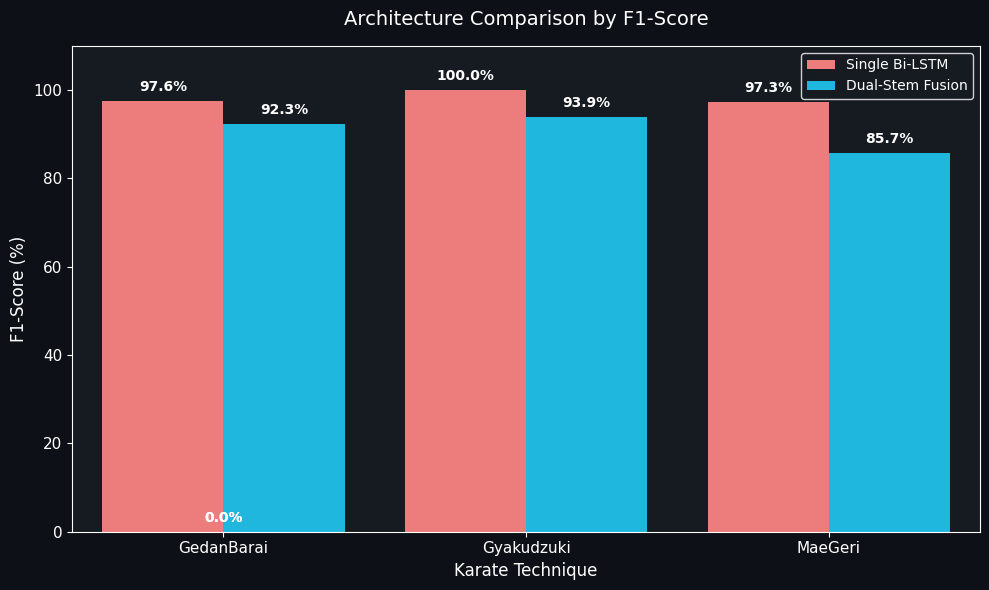


📊 F1-Score Improvement Summary:
Technique          Old F1   New F1    Delta
--------------------------------------------
GedanBarai          97.6%    92.3%  ▼5.2%
Gyakudzuki         100.0%    93.9%  ▼6.1%
MaeGeri             97.3%    85.7%  ▼11.6%

✅ Metadata saved to: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_1151\model_metadata.json
🏁 COMPLETE! All models and reports are secured in the Run folder.


In [9]:


# ==============================================================================
# ── 8. FINAL COMPARISON EXPORT (CSV, Plot, JSON) ──────────────────────────────
# ==============================================================================
print("\n📊 Generating Final Comparison Reports...")

report_new = classification_report(y_true, y_pred_new, target_names=CLASS_NAMES, output_dict=True)
report_old = classification_report(y_true, y_pred_old, target_names=CLASS_NAMES, output_dict=True)

comparison_data = []
csv_stats = []

for cls in CLASS_NAMES:
    old_f1 = report_old[cls]['f1-score'] * 100
    new_f1 = report_new[cls]['f1-score'] * 100
    
    comparison_data.append({'Technique': cls, 'F1-Score': old_f1, 'Model': 'Single Bi-LSTM'})
    comparison_data.append({'Technique': cls, 'F1-Score': new_f1, 'Model': 'Dual-Stem Fusion'})
    
    csv_stats.append({
        'Technique': cls,
        'Support': report_new[cls]['support'],
        'Baseline_F1': round(old_f1, 2),
        'DualStem_F1': round(new_f1, 2),
        'Delta_Improvement': round(new_f1 - old_f1, 2),
        'Precision': round(report_new[cls]['precision'] * 100, 2),
        'Recall': round(report_new[cls]['recall'] * 100, 2)
    })

# Save CSV
csv_path = os.path.join(RUN_SAVE_DIR, 'detailed_performance_report.csv')
pd.DataFrame(csv_stats).to_csv(csv_path, index=False)
print(f"📄 CSV Report saved: {csv_path}")

# Plot Comparison
plt.figure(figsize=(10, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor('#161B22')

sns.barplot(
    data=pd.DataFrame(comparison_data),
    x='Technique', y='F1-Score', hue='Model',
    palette={'Single Bi-LSTM': '#FF6B6B', 'Dual-Stem Fusion': '#00C9FF'},
    ax=ax
)

plt.title('Architecture Comparison by F1-Score', color='white', fontsize=14, pad=15)
plt.ylabel('F1-Score (%)', color='white', fontsize=12)
plt.xlabel('Karate Technique', color='white', fontsize=12)
plt.ylim(0, 110)
plt.tick_params(colors='white', labelsize=11)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10),
                textcoords='offset points', color='white', fontweight='bold')

plt.legend(facecolor='#161B22', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.savefig(os.path.join(RUN_SAVE_DIR, 'model_comparison.png'), dpi=150, facecolor=BG_COLOR)
plt.show()

# Print Delta Summary
print("\n📊 F1-Score Improvement Summary:")
print(f"{'Technique':<16} {'Old F1':>8} {'New F1':>8} {'Delta':>8}")
print("-" * 44)
for row in csv_stats:
    delta = row['Delta_Improvement']
    symbol = '▲' if delta > 0 else '▼'
    print(f"{row['Technique']:<16} {row['Baseline_F1']:>7.1f}% {row['DualStem_F1']:>7.1f}%  {symbol}{abs(delta):.1f}%")

# Save Metadata JSON
meta_path = os.path.join(RUN_SAVE_DIR, 'model_metadata.json')
meta = {
    'classes': CLASS_NAMES,
    'seq_len': SEQ_LEN,
    'dual_stem_accuracy': float(test_acc),
    'trained_at': datetime.datetime.now().isoformat()
}

with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f"\n✅ Metadata saved to: {meta_path}")
print("🏁 COMPLETE! All models and reports are secured in the Run folder.")

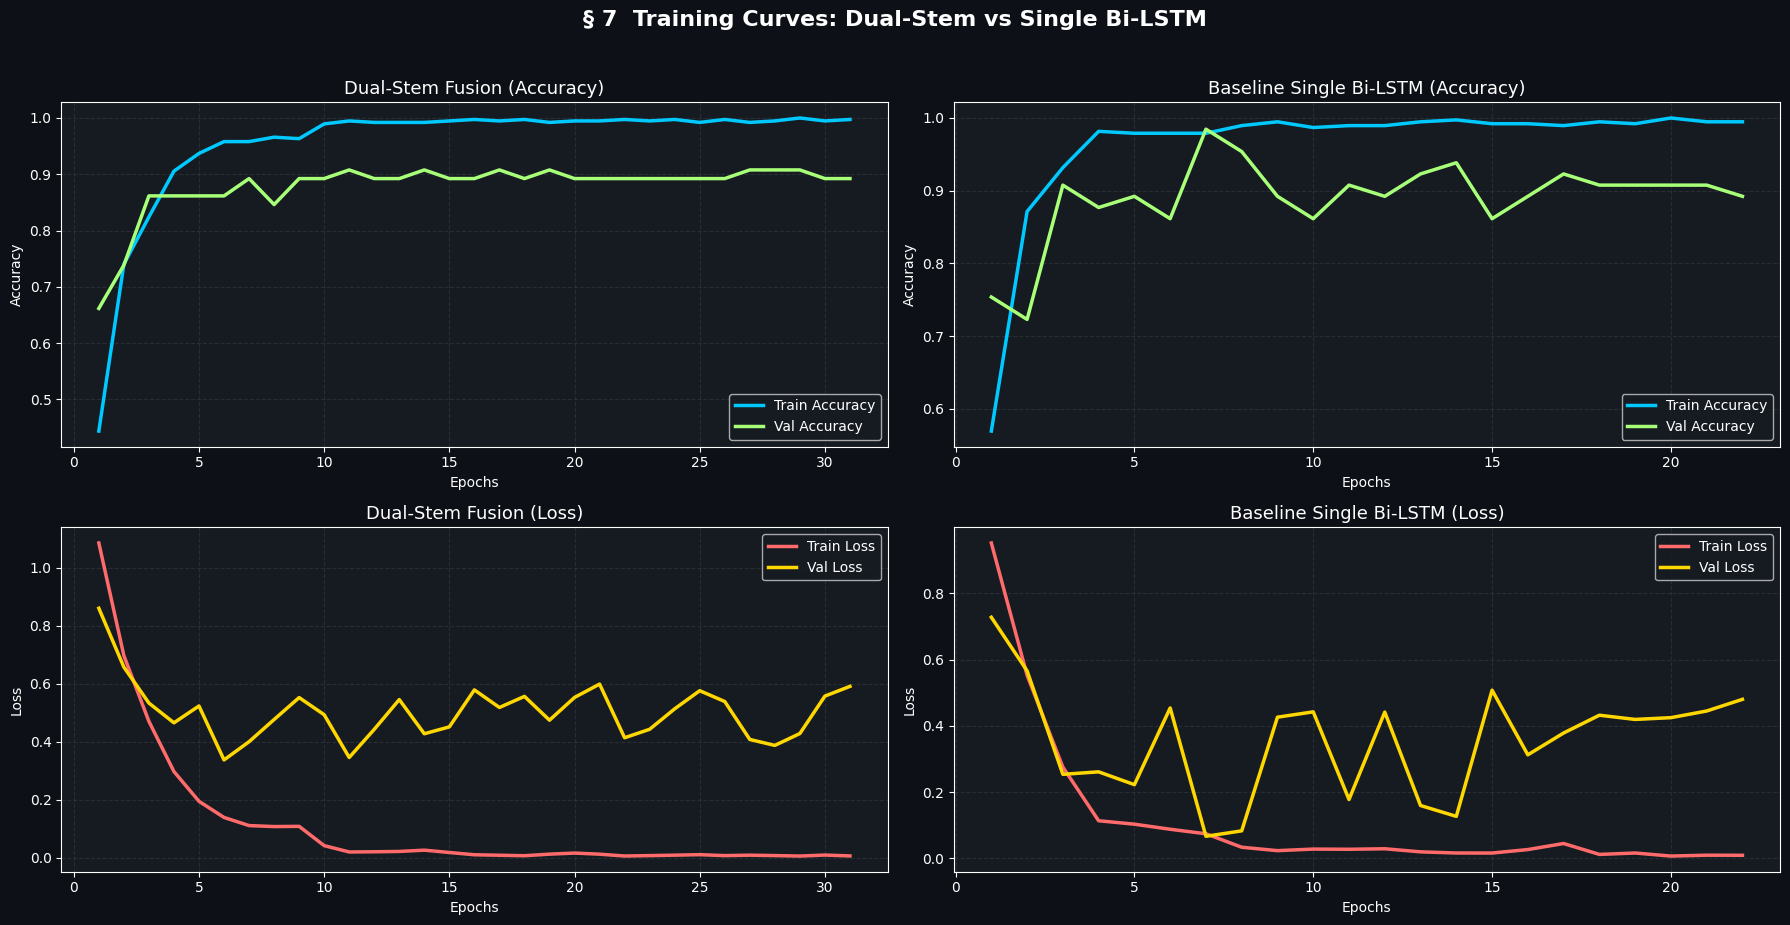

✅ Training curves saved to: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_1151\training_curves_comparison.png


In [10]:
# ==============================================================================
# ── 9. PLOT TRAINING CURVES (ACCURACY & LOSS) ─────────────────────────────────
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor=BG_COLOR)
fig.suptitle('§ 7  Training Curves: Dual-Stem vs Single Bi-LSTM', fontsize=16, fontweight='bold', color='white', y=0.95)

def plot_learning_curve(ax, hist_dict, title, metric, val_metric, color_train, color_val, ylabel):
    epochs = range(1, len(hist_dict[metric]) + 1)
    ax.plot(epochs, hist_dict[metric], color=color_train, linewidth=2.5, label=f'Train {ylabel}')
    ax.plot(epochs, hist_dict[val_metric], color=color_val, linewidth=2.5, label=f'Val {ylabel}')
    ax.set_title(title, color='white', fontsize=13)
    ax.set_xlabel('Epochs', color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.tick_params(colors='white')
    ax.set_facecolor('#161B22')
    ax.legend(facecolor='#161B22', labelcolor='white')
    ax.grid(True, color='#30363D', linestyle='--', alpha=0.7)

# 1. Dual-Stem Accuracy
plot_learning_curve(axes[0, 0], history.history, 'Dual-Stem Fusion (Accuracy)', 'accuracy', 'val_accuracy', '#00C9FF', '#A8FF78', 'Accuracy')
# 2. Dual-Stem Loss
plot_learning_curve(axes[1, 0], history.history, 'Dual-Stem Fusion (Loss)', 'loss', 'val_loss', '#FF6B6B', '#FFD700', 'Loss')

# 3. Single Bi-LSTM Accuracy
plot_learning_curve(axes[0, 1], history_old.history, 'Baseline Single Bi-LSTM (Accuracy)', 'accuracy', 'val_accuracy', '#00C9FF', '#A8FF78', 'Accuracy')
# 4. Single Bi-LSTM Loss
plot_learning_curve(axes[1, 1], history_old.history, 'Baseline Single Bi-LSTM (Loss)', 'loss', 'val_loss', '#FF6B6B', '#FFD700', 'Loss')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])

# Save it to the current run folder!
curves_path = os.path.join(RUN_SAVE_DIR, 'training_curves_comparison.png')
plt.savefig(curves_path, dpi=150, facecolor=BG_COLOR)
plt.show()

print(f"✅ Training curves saved to: {curves_path}")

In [12]:
# ==============================================================================
# ── 10. VERIFY SAVED "JACKPOT" MODELS ─────────────────────────────────────────
# ==============================================================================
import os
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

# 👉 CHANGE THIS FOLDER NAME to the one that had the 100% CSV if it wasn't May21_2217
TARGET_RUN_DIR = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_0044"

print(f"🔍 Loading models from: {TARGET_RUN_DIR}\n")

# 1. Load the Models directly from the folder
print("Loading Dual-Stem...")
jackpot_dual = load_model(os.path.join(TARGET_RUN_DIR, 'best_dual_stem_fusion.keras'))

print("Loading Single Bi-LSTM...")
jackpot_single = load_model(os.path.join(TARGET_RUN_DIR, 'best_single_bilstm.keras'))

# 2. Run Predictions using the exact same test data
print("\n⚙️ Running predictions on the test set...")
pred_dual = np.argmax(jackpot_dual.predict([X_test_upper, X_test_lower], verbose=0), axis=1)
pred_single = np.argmax(jackpot_single.predict(X_test_full, verbose=0), axis=1)

# 3. Print Results to Prove it!
print("\n" + "="*50)
print("🏆 VERIFICATION: JACKPOT DUAL-STEM")
print("="*50)
print(classification_report(y_test, pred_dual, target_names=CLASS_NAMES, digits=4))

print("\n" + "="*50)
print("🏆 VERIFICATION: JACKPOT SINGLE BI-LSTM")
print("="*50)
print(classification_report(y_test, pred_single, target_names=CLASS_NAMES, digits=4))

🔍 Loading models from: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_0044

Loading Dual-Stem...
Loading Single Bi-LSTM...

⚙️ Running predictions on the test set...

🏆 VERIFICATION: JACKPOT DUAL-STEM
              precision    recall  f1-score   support

  GedanBarai     1.0000    0.9048    0.9500        21
  Gyakudzuki     1.0000    1.0000    1.0000        26
     MaeGeri     0.9000    1.0000    0.9474        18

    accuracy                         0.9692        65
   macro avg     0.9667    0.9683    0.9658        65
weighted avg     0.9723    0.9692    0.9693        65


🏆 VERIFICATION: JACKPOT SINGLE BI-LSTM
              precision    recall  f1-score   support

  GedanBarai     1.0000    0.9048    0.9500        21
  Gyakudzuki     1.0000    0.9231    0.9600        26
     MaeGeri     0.8182    1.0000    0.9000        18

    accuracy                         0.9385        65
   macro avg     0.9394    0.9426    0.9367        65
weighted avg     0.949

In [13]:
# ==============================================================================
# ── 10. VERIFY PRODUCTION MODELS ──────────────────────────────────────────────
# ==============================================================================
import os
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

# Pointing to your new Production folder
PRODUCTION_DIR = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Production_Best"

print(f"🔍 Loading champion models from: {PRODUCTION_DIR}\n")

# 1. Load the Models directly from the folder
print("Loading Dual-Stem...")
production_dual = load_model(os.path.join(PRODUCTION_DIR, 'best_dual_stem_fusion.keras'))

print("Loading Single Bi-LSTM...")
production_single = load_model(os.path.join(PRODUCTION_DIR, 'best_single_bilstm.keras'))

# 2. Run Predictions using the exact same test data
print("\n⚙️ Running predictions on the test set...")
pred_dual = np.argmax(production_dual.predict([X_test_upper, X_test_lower], verbose=0), axis=1)
pred_single = np.argmax(production_single.predict(X_test_full, verbose=0), axis=1)

# 3. Print Results to Prove it!
print("\n" + "="*50)
print("🏆 VERIFICATION: PRODUCTION DUAL-STEM")
print("="*50)
print(classification_report(y_test, pred_dual, target_names=CLASS_NAMES, digits=4))

print("\n" + "="*50)
print("🏆 VERIFICATION: PRODUCTION SINGLE BI-LSTM")
print("="*50)
print(classification_report(y_test, pred_single, target_names=CLASS_NAMES, digits=4))

🔍 Loading champion models from: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Production_Best

Loading Dual-Stem...
Loading Single Bi-LSTM...

⚙️ Running predictions on the test set...

🏆 VERIFICATION: PRODUCTION DUAL-STEM
              precision    recall  f1-score   support

  GedanBarai     1.0000    0.9048    0.9500        21
  Gyakudzuki     1.0000    1.0000    1.0000        26
     MaeGeri     0.9000    1.0000    0.9474        18

    accuracy                         0.9692        65
   macro avg     0.9667    0.9683    0.9658        65
weighted avg     0.9723    0.9692    0.9693        65


🏆 VERIFICATION: PRODUCTION SINGLE BI-LSTM
              precision    recall  f1-score   support

  GedanBarai     1.0000    0.9524    0.9756        21
  Gyakudzuki     1.0000    1.0000    1.0000        26
     MaeGeri     0.9474    1.0000    0.9730        18

    accuracy                         0.9846        65
   macro avg     0.9825    0.9841    0.9829        65
weight